# Python OOP Series - Part 5: Magic Method (Dunder Methods)
Welcome to part 5 of my Python OOP series

Previous Notebook: Part 4(https://www.kaggle.com/code/aymanhatabah/python-oop-inheritance-subclasses)

### Introduction
Dunder methods mean "Double Underscore" methods. They start and end with `__`, like `__init__`. People also call them "Magic Methods". 
Popular AI libraries like **NumPy**, **Pandas**, and **PyTorch** use these methods to make code simple and easy to read. In this notebook, we will learn how the most important Dunder methods work in AI projects using very easy examples because i'm beginner.


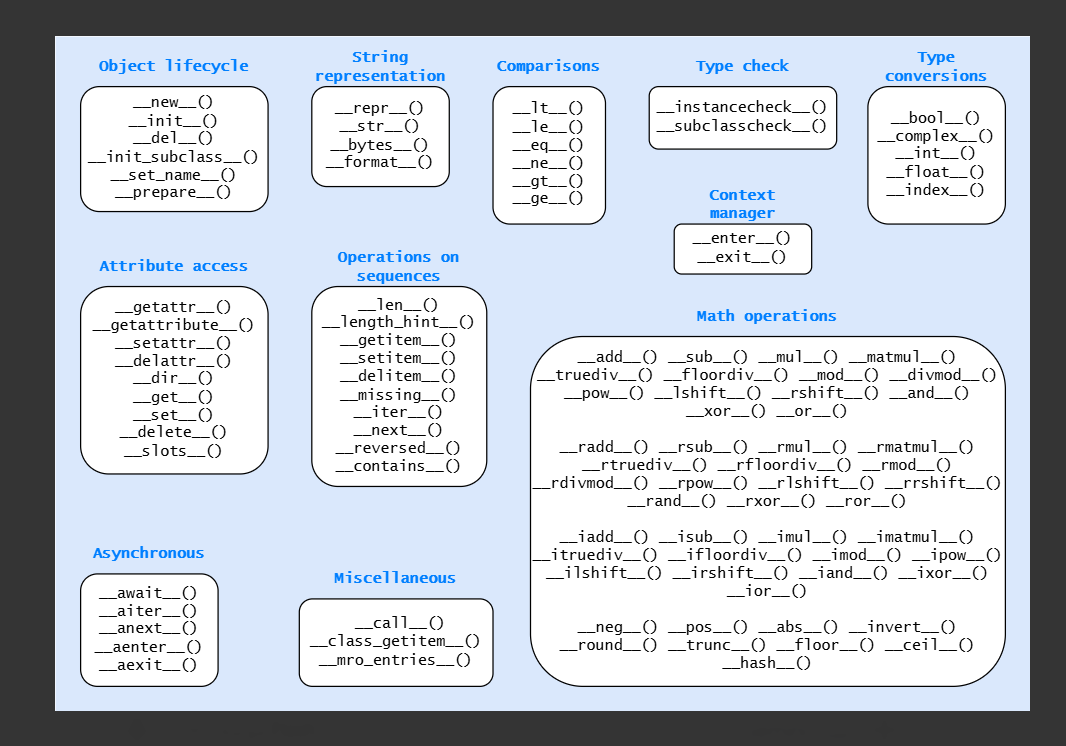

## 1. Creating and Printing a Model (`__init__`, `__repr__`, and `__str__`)

* **`__init__`**: This is the constructor. When you create a model or a layer in **PyTorch**, this method runs automatically to set up the weights and parameters.
* **`__repr__`**: This shows technical details about the object. AI libraries use it so developers can print the model architecture and debug code easily.
* **`__str__`**: This shows a friendly, simple message for regular users when they print the model.

In [1]:
class SimpleAIModel:
    """
    A simple AI model class to show how we initialize and print objects.
    """
    def __init__(self, model_name: str, weight: float):
        """
        Runs automatically to set up the model name and weight parameter.
        """
        self.model_name = model_name
        self.weight = weight
        
    def __repr__(self) -> str:
        """
        Returns technical details for developers to debug.
        """
        return f"SimpleAIModel(model_name='{self.model_name}', weight={self.weight})"
        
    def __str__(self) -> str:
        """
        Returns a friendly message for regular users.
        """
        return f"Model: {self.model_name} | Status: Ready for Training"

# --- Testing the Code ---
# Create the model instance (calls __init__)
my_model = SimpleAIModel(model_name="Linear_Regression_V1", weight=2.8)

# Technical print (calls __repr__)
print("Technical message")
print(repr(my_model))

# Friendly print (calls __str__)
print("\n  message for Users:")
print(str(my_model))

Technical message
SimpleAIModel(model_name='Linear_Regression_V1', weight=2.8)

  message for Users:
Model: Linear_Regression_V1 | Status: Ready for Training


## 2. Managing Data Batches (`__len__` and `__getitem__`)

AI projects need to handle large datasets. Frameworks like **Pandas** and **PyTorch** use these two methods to make custom data objects act like standard Python lists.
* **`__len__`**: Lets you use `len(dataset)` so the training loop knows the total number of data samples.
* **`__getitem__`**: Lets you use brackets like `dataset[0]` to fetch a specific data row or image using its index.

In [2]:
class AIDataset:
    """
    A simple dataset class that acts like a Python list for AI data.
    """
    def __init__(self, features: list, labels: list):
        """
        Saves features and labels inside the dataset.
        """
        self.features = features
        self.labels = labels
        
    def __len__(self) -> int:
        """
        Returns the total number of samples.
        """
        return len(self.features)
        
    def __getitem__(self, index: int) -> dict:
        """
        Returns one data sample and its label using its index position.
        """
        return {
            "feature_value": self.features[index],
            "label_value": self.labels[index]
        }

# --- Testing the Code ---
X_data = [0.15, 0.44, 0.89]
y_data = [0, 1, 1]

my_dataset = AIDataset(X_data, y_data)

print(f"Total dataset rows (calls __len__): {len(my_dataset)}")
print(f"Getting sample at index 1 (calls __getitem__): {my_dataset[1]}")

Total dataset rows (calls __len__): 3
Getting sample at index 1 (calls __getitem__): {'feature_value': 0.44, 'label_value': 1}


## 3. Running the Model Forward Pass (`__call__`)

* **`__call__`**: This method allows you to use a class instance exactly like a normal function using simple parentheses `()`.
* **Why it matters in AI**: This is the core secret of **PyTorch**. When you want to pass data through a neural network to get a prediction, you do not write `model.predict(data)`. You just write `model(data)`. This automatically calls the `__call__` method behind the scenes.

In [3]:
class NeuralNetworkLayer:
    """
    Simulates a neural network layer that can be called like a function.
    """
    def __init__(self, bias: float):
        """
        Saves a basic bias number for our calculation.
        """
        self.bias = bias
        
    def __call__(self, input_value: float) -> float:
        """
        Runs automatically when we use () on the object instance.
        """
        print("[__call__] is processing the input data now...")
        # Simple forward pass formula: input + bias
        return input_value + self.bias

# --- Testing the Code ---
# Create the layer object
layer = NeuralNetworkLayer(bias=5.0)

# Use the object like a function using ()
output = layer(10.0)
print(f"Layer Output Result: {output}")

[__call__] is processing the input data now...
Layer Output Result: 15.0


## 4. Tensor and Matrix Operations (`__mul__` and `__matmul__`)

AI computing depends heavily on matrix math. To keep the code clean, Python allows us to overload mathematical symbols.
* **`__mul__`**: Overloads the `*` symbol. **NumPy** and **PyTorch** use it to multiply a whole tensor by a single number (scalar multiplication).
* **`__matmul__`**: Overloads the `@` symbol. AI libraries use it to perform real Matrix Multiplication (Dot Product), which is the most common math operation in Deep Learning.

In [4]:
class SimpleTensor:
    """
    A simple class to show how math symbols work with AI data tensors.
    """
    def __init__(self, data_list: list):
        self.data_list = data_list
        
    def __mul__(self, scalar: float) -> list:
        """
        Multiplies every item inside the list by a single number using '*'.
        """
        print(f"[__mul__] Scaling data by {scalar}...")
        return [item * scalar for item in self.data_list]
        
    def __matmul__(self, other) -> float:
        """
        Performs dot product matrix multiplication using the '@' symbol.
        """
        print("[__matmul__] Multiplying matrices together...")
        # Simple dot product simulation for two lists
        return sum(a * b for a, b in zip(self.data_list, other.data_list))
        #zip pairs up corresponding elements index-by-index.

# --- Testing the Code ---
tensor_a = SimpleTensor([1.0, 2.0, 3.0])
tensor_b = SimpleTensor([4.0, 5.0, 6.0])

# Scalar multiplication using '*'
scaled_result = tensor_a * 3.0
print(f"Scalar Multiplication Result: {scaled_result}")

# Matrix multiplication using '@'
matrix_result = tensor_a @ tensor_b
print(f"Matrix Multiplication Result: {matrix_result}")

[__mul__] Scaling data by 3.0...
Scalar Multiplication Result: [3.0, 6.0, 9.0]
[__matmul__] Multiplying matrices together...
Matrix Multiplication Result: 32.0


## Summary: Dunder Methods Cheat-Sheet for AI

Here is a quick summary of the magic methods we learned and how AI libraries use them behind the scenes:

| Dunder Method | What it does | AI Library Example |
| :--- | :--- | :--- |
| **`__init__`** | Sets up the model or layer parameters | Creating a layer in **PyTorch** (`nn.Linear`) |
| **`__repr__` / `__str__`** | Prints the object details cleanly | Printing the architecture of a neural network |
| **`__len__`** | Returns the total size of the data | Finding total batches in a **PyTorch DataLoader** |
| **`__getitem__`** | Selects a sample using index brackets `[]` | Slicing data rows in **Pandas** or **NumPy** |
| **`__call__`** | Makes an object work like a function `()` | Running a forward pass in **PyTorch** (`model(data)`) |
| **`__mul__`** | Changes how the `*` symbol works | Multiplying a tensor by a single number in **NumPy** |
| **`__matmul__`** | Changes how the `@` symbol works | Doing real Matrix Multiplication in **NumPy** or **PyTorch** |

Now you can see that Dunder methods are not magic—they are just tools to make your AI code clean, fast, and professional

....... Next Step: Part 6 - Property Decorators - Getters, Setters, and Deleters